# Midstance Pressure

1. Load data
2. Pre-process
3. Segment steps (shared stance-peak windows)
4. Find midstance pressure per step (first sample where forefoot > heel)
5. Visualise
6. Export

## 0. Imports & Parameters

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.signal import find_peaks, savgol_filter

# Sensor groups
HEEL_SENSORS     = ['pressure_08', 'pressure_11']
FOREFOOT_SENSORS = ['pressure_02', 'pressure_04', 'pressure_05', 'pressure_06', 'pressure_09']

# Step segmentation parameters
SMOOTH_WIN    = 11
SMOOTH_POLY   = 2
BIG_PEAK_DIST = 50
BIG_PEAK_PROM = 200
BIG_PEAK_HT   = 500


## 1. Load Data

In [2]:
grass_df = pd.read_csv('data2/grass_dry.csv',    low_memory=False)
conc_df  = pd.read_csv('data2/concrete_dry.csv', low_memory=False)
brick_df = pd.read_csv('data2/brick_dry.csv',    low_memory=False)

print('grass:',    grass_df.shape)
print('concrete:', conc_df.shape)
print('brick:',    brick_df.shape)


grass: (2979, 24)
concrete: (4349, 24)
brick: (2940, 24)


## 2. Pre-process

In [3]:
def preprocess(df):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['time_sec']  = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    return df

grass_rdf = preprocess(grass_df[grass_df['sole_id'] == 1])
grass_ldf = preprocess(grass_df[grass_df['sole_id'] == 2])
conc_rdf  = preprocess(conc_df[conc_df['sole_id']   == 1])
conc_ldf  = preprocess(conc_df[conc_df['sole_id']   == 2])
brick_rdf = preprocess(brick_df[brick_df['sole_id'] == 1])
brick_ldf = preprocess(brick_df[brick_df['sole_id'] == 2])

for name, d in [('grass  right', grass_rdf), ('grass  left ', grass_ldf),
                ('conc   right', conc_rdf),  ('conc   left ', conc_ldf),
                ('brick  right', brick_rdf), ('brick  left ', brick_ldf)]:
    print(f'{name}: {len(d):5d} rows | {d["time_sec"].iloc[-1]:.1f} s')


grass  right:  1489 rows | 25.2 s
grass  left :  1490 rows | 25.2 s
conc   right:  2163 rows | 37.1 s
conc   left :  2186 rows | 36.8 s
brick  right:  1483 rows | 25.4 s
brick  left :  1457 rows | 24.6 s


## 3. Step Segmentation

Finds stance peaks from the summed heel signal. Consecutive peak pairs define each step window.

In [4]:
def find_step_windows(df, sensors=HEEL_SENSORS):
    """Return array of stance-peak indices from the summed heel signal."""
    y_comb = sum(
        pd.to_numeric(df[s], errors='coerce').fillna(0).to_numpy(dtype=float)
        for s in sensors if s in df.columns
    )
    n  = len(y_comb)
    sw = min(SMOOTH_WIN, n - (0 if n % 2 == 1 else 1))
    if sw % 2 == 0: sw -= 1
    if sw <= SMOOTH_POLY:
        sw = SMOOTH_POLY + 3 + (1 if (SMOOTH_POLY + 3) % 2 == 0 else 0)
    y_sm = savgol_filter(y_comb, window_length=sw, polyorder=min(SMOOTH_POLY, sw - 1))
    peaks, _ = find_peaks(y_sm, distance=BIG_PEAK_DIST,
                           prominence=BIG_PEAK_PROM, height=BIG_PEAK_HT)
    return peaks


## 4. Midstance Extraction — Minimum Normalised Difference

Midstance = the sample where heel and forefoot loading are most **balanced** — the genuine transition point between heel-dominant and forefoot-dominant loading.

**Method:**
1. Find heel contact `c` = argmin of heel signal in [p1, p2]
2. From `c` to `p2`, compute the absolute difference between normalised heel and forefoot at every sample:
   `|heel_sig[j]/2 - fore_sig[j]/5|`
3. Midstance index `m` = the sample where this difference is smallest (most balanced)

Dividing by sensor count (2 heel, 5 forefoot) makes the two regions directly comparable before taking the difference.

In [5]:
def extract_midstance_pressure(
    df,
    surface_label      = 'unknown',
    foot_label         = 'unknown',
    time_col           = 'time_sec',
    heel_sensors       = None,
    forefoot_sensors   = None,
    # step segmentation parameters
    smooth_win         = 11,
    smooth_poly        = 2,
    peak_dist          = 50,
    peak_prom          = 200,
    peak_ht            = 500,
):
    """
    Given a preprocessed dataframe for one surface + foot, segments steps
    and finds midstance for each step.

    Midstance = sample where normalised heel and forefoot pressure are most
    balanced (minimum absolute difference). Normalisation divides each
    region's sum by its sensor count so they are directly comparable.

    Parameters
    ----------
    df               : preprocessed DataFrame with pressure columns and time_col
    surface_label    : label string for output (e.g. 'grass')
    foot_label       : label string for output (e.g. 'left')
    time_col         : name of the time column in df
    heel_sensors     : list of heel sensor column names (defaults to HEEL_SENSORS)
    forefoot_sensors : list of forefoot sensor column names (defaults to FOREFOOT_SENSORS)
    smooth_win       : Savitzky-Golay window length for step segmentation
    smooth_poly      : Savitzky-Golay polynomial order
    peak_dist        : minimum samples between stance peaks
    peak_prom        : minimum peak prominence
    peak_ht          : minimum peak height

    Returns
    -------
    DataFrame with one row per step:
        surface, foot, step_id,
        contact_time_sec, midstance_time_sec,
        midstance_heel, midstance_forefoot, midstance_difference
    """
    from scipy.signal import find_peaks, savgol_filter

    if heel_sensors     is None: heel_sensors     = HEEL_SENSORS
    if forefoot_sensors is None: forefoot_sensors = FOREFOOT_SENSORS

    df = df.copy().reset_index(drop=True)

    heel_cols = [c for c in heel_sensors     if c in df.columns]
    fore_cols = [c for c in forefoot_sensors if c in df.columns]
    n_heel, n_fore = len(heel_cols), len(fore_cols)

    heel_sig  = df[heel_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1).fillna(0).values
    fore_sig  = df[fore_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1).fillna(0).values
    heel_norm = heel_sig / n_heel
    fore_norm = fore_sig / n_fore

    # ── Step segmentation (internal) ─────────────────────────────────────
    n  = len(heel_sig)
    sw = min(smooth_win, n - (0 if n % 2 == 1 else 1))
    if sw % 2 == 0: sw -= 1
    if sw <= smooth_poly:
        sw = smooth_poly + 3 + (1 if (smooth_poly + 3) % 2 == 0 else 0)
    y_sm = savgol_filter(heel_sig, window_length=sw, polyorder=min(smooth_poly, sw - 1))
    big_peaks, _ = find_peaks(y_sm, distance=peak_dist,
                               prominence=peak_prom, height=peak_ht)

    if len(big_peaks) < 2:
        return pd.DataFrame()

    # ── Midstance extraction ──────────────────────────────────────────────
    results = []
    for i in range(len(big_peaks) - 1):
        p1, p2 = big_peaks[i], big_peaks[i + 1]

        # heel contact = minimum of heel signal in the window
        c_idx = p1 + int(np.argmin(heel_sig[p1:p2]))

        # absolute normalised difference from contact to end of window
        diff    = np.abs(heel_norm[c_idx:p2] - fore_norm[c_idx:p2])
        mid_idx = c_idx + int(np.argmin(diff))

        results.append({
            'surface'              : surface_label,
            'foot'                 : foot_label,
            'step_id'              : i + 1,
            'contact_time_sec'     : float(df[time_col].iloc[c_idx]),
            'midstance_time_sec'   : float(df[time_col].iloc[mid_idx]),
            'midstance_heel'       : float(heel_norm[mid_idx]),
            'midstance_forefoot'   : float(fore_norm[mid_idx]),
            'midstance_difference' : float(diff[mid_idx - c_idx]),
        })

    return pd.DataFrame(results), big_peaks

In [6]:
df_lookup = {
    'grass':    {'left': grass_ldf,  'right': grass_rdf},
    'concrete': {'left': conc_ldf,   'right': conc_rdf},
    'brick':    {'left': brick_ldf,  'right': brick_rdf},
}

all_mid      = []
peaks_lookup = {}

for surface, feet in df_lookup.items():
    for foot, df in feet.items():
        mid_df, big_peaks = extract_midstance_pressure(df, surface, foot)
        peaks_lookup[(surface, foot)] = big_peaks
        all_mid.append(mid_df)
        print(f'{surface:10s} {foot:6s} -> {len(mid_df):3d} steps | '
              f'mean midstance heel: {mid_df["midstance_heel"].mean():.1f} | '
              f'mean midstance forefoot: {mid_df["midstance_forefoot"].mean():.1f} | '
              f'mean difference: {mid_df["midstance_difference"].mean():.1f}')

mid_all = pd.concat(all_mid, ignore_index=True)
print(f'\nTotal steps: {len(mid_all)}')
print(mid_all.head(10).to_string(index=False))

grass      left   ->  20 steps | mean midstance heel: 391.8 | mean midstance forefoot: 388.2 | mean difference: 9.5
grass      right  ->  20 steps | mean midstance heel: 273.0 | mean midstance forefoot: 281.4 | mean difference: 12.6
concrete   left   ->  29 steps | mean midstance heel: 364.0 | mean midstance forefoot: 356.1 | mean difference: 17.7
concrete   right  ->  28 steps | mean midstance heel: 267.9 | mean midstance forefoot: 277.5 | mean difference: 10.2
brick      left   ->  20 steps | mean midstance heel: 368.1 | mean midstance forefoot: 366.9 | mean difference: 18.7
brick      right  ->  21 steps | mean midstance heel: 275.1 | mean midstance forefoot: 280.6 | mean difference: 14.3

Total steps: 138
surface foot  step_id  contact_time_sec  midstance_time_sec  midstance_heel  midstance_forefoot  midstance_difference
  grass left        1             1.264               1.744           368.0               369.8                   1.8
  grass left        2             2.416      

## 5. Visualise

For each surface / foot: forefoot vs heel signal over time with midstance marked.

- **Vertical dotted line** — midstance timestamp
- **Horizontal dashed line** — midstance pressure, drawn across the step window
- **Orange** = real crossover found | **Grey** = fallback (window midpoint)

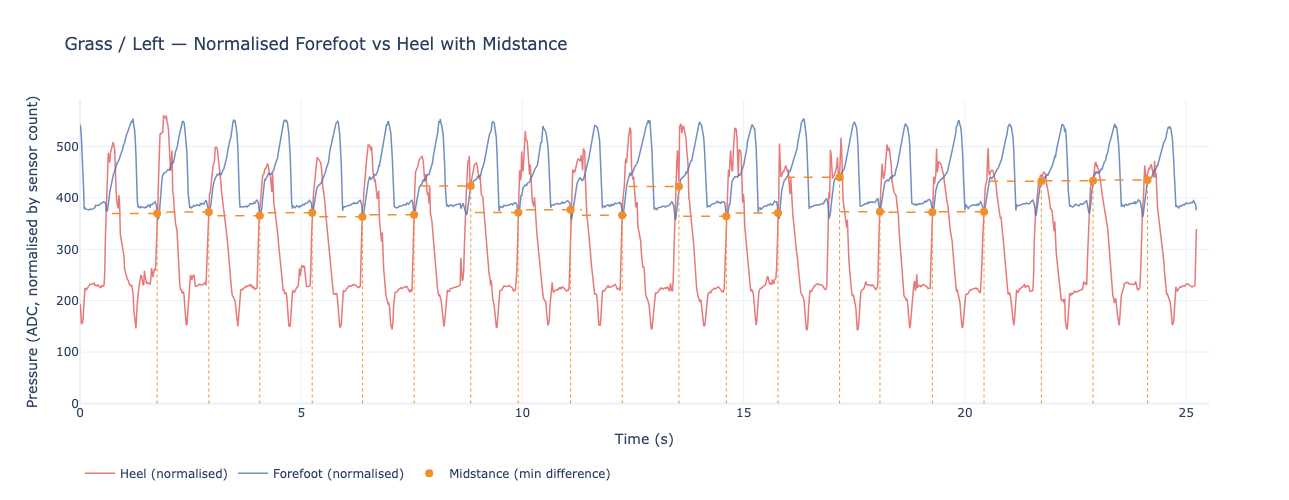

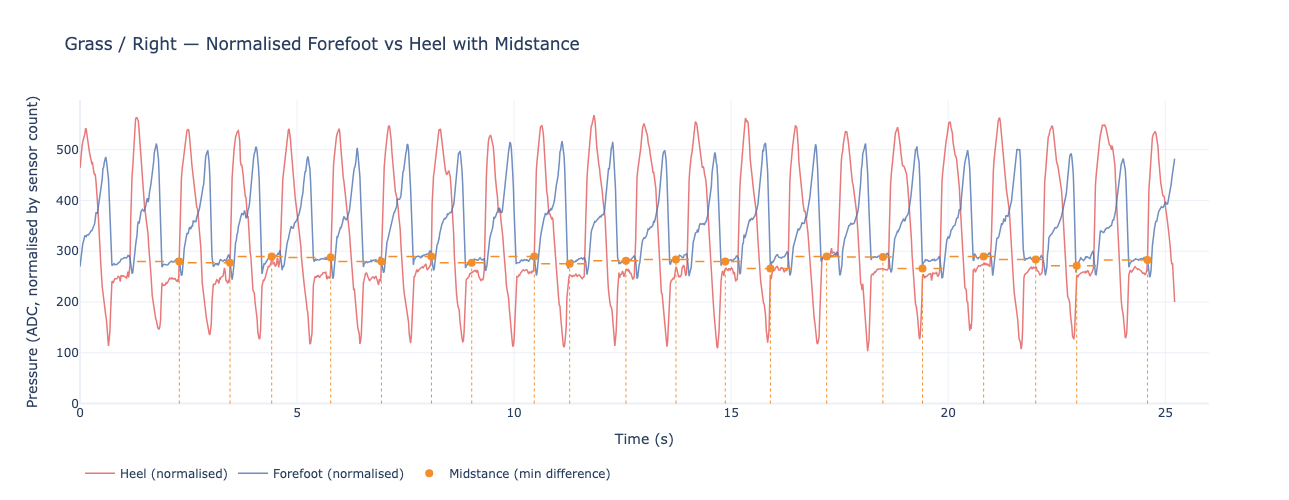

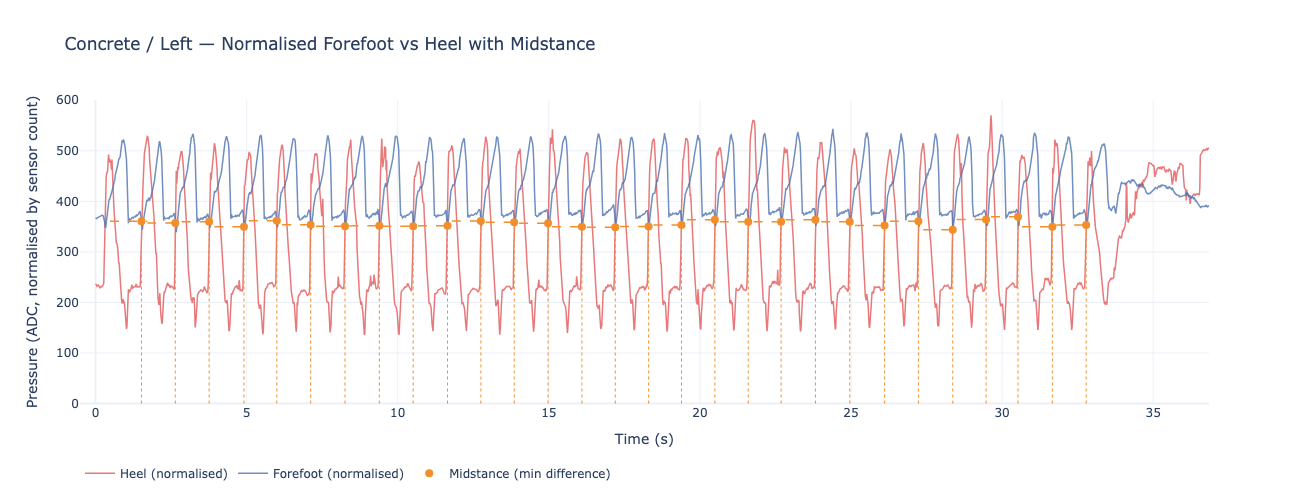

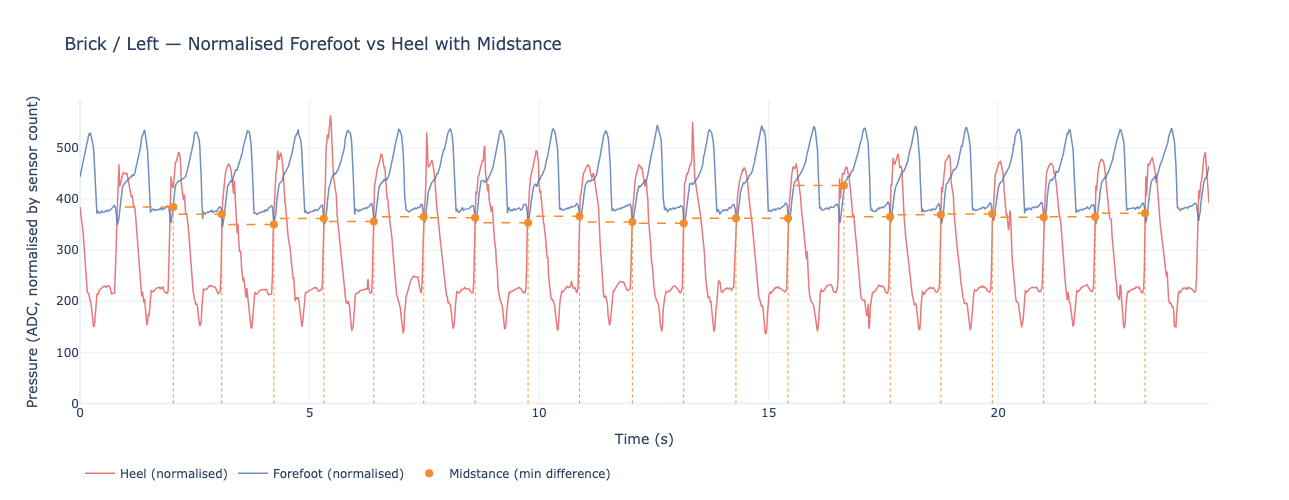

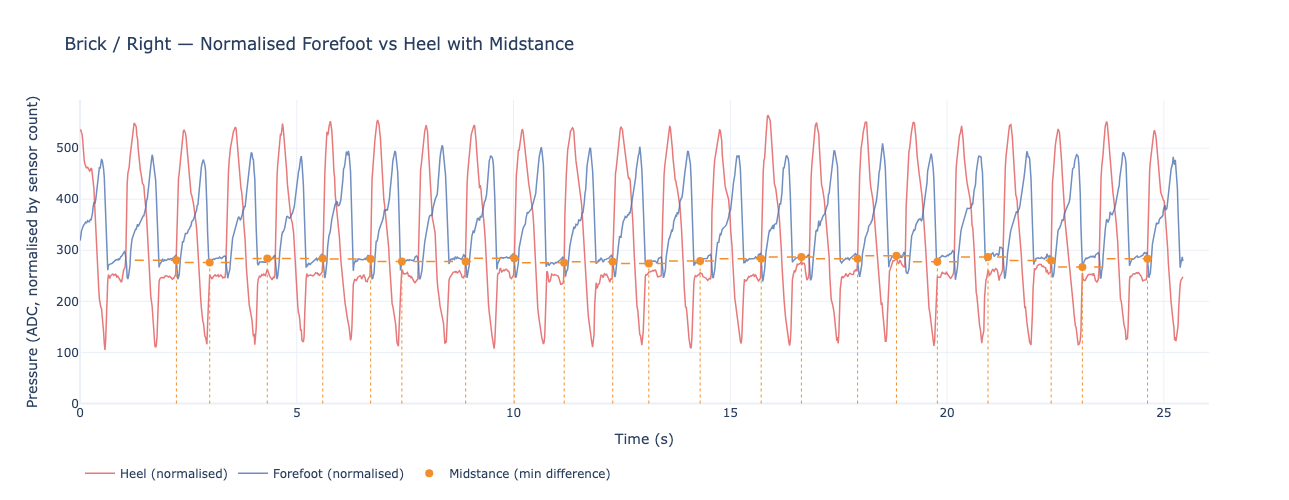

In [9]:
for (surface, foot), big_peaks in peaks_lookup.items():
    df      = df_lookup[surface][foot]
    mid_df  = mid_all[(mid_all['surface'] == surface) & (mid_all['foot'] == foot)]
    t       = df['time_sec'].values

    fore_cols = [c for c in FOREFOOT_SENSORS if c in df.columns]
    heel_cols = [c for c in HEEL_SENSORS     if c in df.columns]
    fore_sig  = df[fore_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1).fillna(0).values / len(fore_cols)
    heel_sig  = df[heel_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1).fillna(0).values / len(heel_cols)

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=t, y=heel_sig, name='Heel (normalised)',
        line=dict(color='#E15759', width=1.5), opacity=0.8
    ))
    fig.add_trace(go.Scatter(
        x=t, y=fore_sig, name='Forefoot (normalised)',
        line=dict(color='#4C72B0', width=1.5), opacity=0.8
    ))

    shown = False
    for _, row in mid_df.iterrows():
        step_idx = int(row['step_id']) - 1
        mid_t    = row['midstance_time_sec']
        mid_p    = row['midstance_forefoot']   # forefoot pressure at midstance

        if 0 <= step_idx < len(big_peaks) - 1:
            x0 = float(t[big_peaks[step_idx]])
            x1 = float(t[big_peaks[step_idx + 1]])
        else:
            x0, x1 = mid_t - 0.15, mid_t + 0.15

        # horizontal dashed line at midstance forefoot pressure across the step window
        fig.add_shape(type='line',
            x0=x0, x1=x1, y0=mid_p, y1=mid_p,
            line=dict(color='#F28E2B', width=1.5, dash='dash'))

        # vertical dotted line at midstance time
        fig.add_shape(type='line',
            x0=mid_t, x1=mid_t, y0=0, y1=mid_p,
            line=dict(color='#F28E2B', width=1, dash='dot'))

        # marker at (midstance_time, midstance_forefoot)
        fig.add_trace(go.Scatter(
            x=[mid_t], y=[mid_p], mode='markers',
            name='Midstance (min difference)',
            marker=dict(size=8, color='#F28E2B', symbol='circle'),
            showlegend=not shown,
        ))
        shown = True

    fig.update_layout(
        title=f'{surface.capitalize()} / {foot.capitalize()} — Normalised Forefoot vs Heel with Midstance',
        xaxis_title='Time (s)',
        yaxis_title='Pressure (ADC, normalised by sensor count)',
        template='plotly_white',
        height=500,
        hovermode='x unified',
        legend=dict(orientation='h', x=0, y=-0.18, yanchor='top'),
    )
    fig.show()

## 6. Export

In [8]:
out = 'midstance_all_surfaces.csv'
mid_all.to_csv(out, index=False)
print(f'Saved {len(mid_all)} rows -> {out}')
print(mid_all.groupby(['surface', 'foot'])['midstance_pressure'].describe().round(1))


Saved 138 rows -> midstance_all_surfaces.csv


KeyError: 'Column not found: midstance_pressure'